In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from scipy.stats import linregress

plt.style.use("ggplot")

In [26]:
engine = create_engine("sqlite:///../bluestock_mf.db")

print("Database Connected Successfully")

Database Connected Successfully


In [27]:
nav = pd.read_sql(
    "SELECT * FROM fact_nav",
    engine
)

performance = pd.read_sql(
    "SELECT * FROM fact_performance",
    engine
)

benchmark = pd.read_sql(
    "SELECT * FROM dim_benchmark",
    engine
)

print("NAV Shape :", nav.shape)
print("Performance Shape :", performance.shape)
print("Benchmark Shape :", benchmark.shape)

NAV Shape : (46000, 3)
Performance Shape : (40, 19)
Benchmark Shape : (8050, 3)


In [29]:
print("NAV Columns:")
print(nav.columns.tolist())

print("\nBenchmark Columns:")
print(benchmark.columns.tolist())

NAV Columns:
['amfi_code', 'date', 'nav']

Benchmark Columns:
['date', 'index_name', 'close_value']


In [30]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [31]:
# Calculate CAGR for each mutual fund

cagr_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    if len(group) > 1:

        beginning_value = group["nav"].iloc[0]
        ending_value = group["nav"].iloc[-1]

        years = (group["date"].iloc[-1] - group["date"].iloc[0]).days / 365.25

        if years > 0:

            cagr = ((ending_value / beginning_value) ** (1 / years) - 1) * 100

        else:

            cagr = np.nan

    else:

        cagr = np.nan

    cagr_list.append({
        "amfi_code": code,
        "CAGR (%)": round(cagr, 2)
    })

cagr_df = pd.DataFrame(cagr_list)

cagr_df.head()

,amfi_code,CAGR (%)
0,100016,2.64
1,100025,4.46
2,100033,30.12
3,101206,23.54
4,101207,7.94


In [32]:
# Annual Risk-Free Rate
risk_free_rate = 0.06

sharpe_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        annual_return = returns.mean() * 252
        annual_volatility = returns.std() * np.sqrt(252)

        if annual_volatility != 0:
            sharpe = (annual_return - risk_free_rate) / annual_volatility
        else:
            sharpe = np.nan

    else:
        sharpe = np.nan

    sharpe_list.append({
        "amfi_code": code,
        "Sharpe": round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df.head()

,amfi_code,Sharpe
0,100016,-0.1671
1,100025,-0.4391
2,100033,1.1201
3,101206,1.0615
4,101207,0.1820


In [33]:
alpha_beta = performance[
    ["amfi_code", "alpha", "beta"]
].copy()

alpha_beta.rename(
    columns={
        "alpha": "Alpha",
        "beta": "Beta"
    },
    inplace=True
)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,119551,0.87,0.89
1,119552,1.78,0.87
2,119598,1.23,0.89
3,119599,1.13,1.04
4,119120,1.60,0.22


In [34]:
drawdown_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = group["nav"] / group["running_max"] - 1

    drawdown_list.append({
        "amfi_code": code,
        "max_drawdown": round(group["drawdown"].min() * 100, 2)
    })

drawdown = pd.DataFrame(drawdown_list)

drawdown.head()

,amfi_code,max_drawdown
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [35]:
scorecard = performance.copy()

scorecard = scorecard.merge(
    cagr_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown,
    on="amfi_code",
    how="left"
)

scorecard["Score"] = (
      scorecard["CAGR (%)"].rank(pct=True) * 35
    + scorecard["Sharpe"].rank(pct=True) * 30
    + scorecard["Alpha"].rank(pct=True) * 15
    + (1 - scorecard["expense_ratio_pct"].rank(pct=True)) * 10
    + (1 - scorecard["max_drawdown"].rank(pct=True)) * 10
)

scorecard = scorecard.sort_values(
    "Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,CAGR (%),Sharpe,Alpha,Beta,max_drawdown,Score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,30.91,1.3382,1.85,0.95,-12.97,80.6875
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,979,1.36,3,High,32.83,1.2060,0.89,1.00,-18.19,77.8125
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,11361,1.46,5,Moderate,30.97,1.4835,1.62,0.96,-11.27,77.6250
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,32.42,0.9652,1.23,0.89,-28.71,75.0000
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,...,28996,1.38,5,High,28.21,1.0240,1.42,1.00,-20.96,71.6250
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,23185,1.38,5,High,30.12,1.1201,0.95,0.91,-16.22,70.6250
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,35124,1.52,4,Very High,32.29,0.9699,0.69,0.98,-31.17,67.7500
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1231,0.66,3,Moderate,21.52,0.9891,1.78,0.87,-11.80,67.2500
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,11.16,13.58,14.26,13.04,0.54,...,2989,1.60,5,High,31.95,1.2632,0.54,0.98,-16.40,66.7500
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,...,37835,1.61,4,High,29.58,1.1603,1.02,0.98,-17.25,66.1250


In [36]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Reports exported successfully!")

Reports exported successfully!


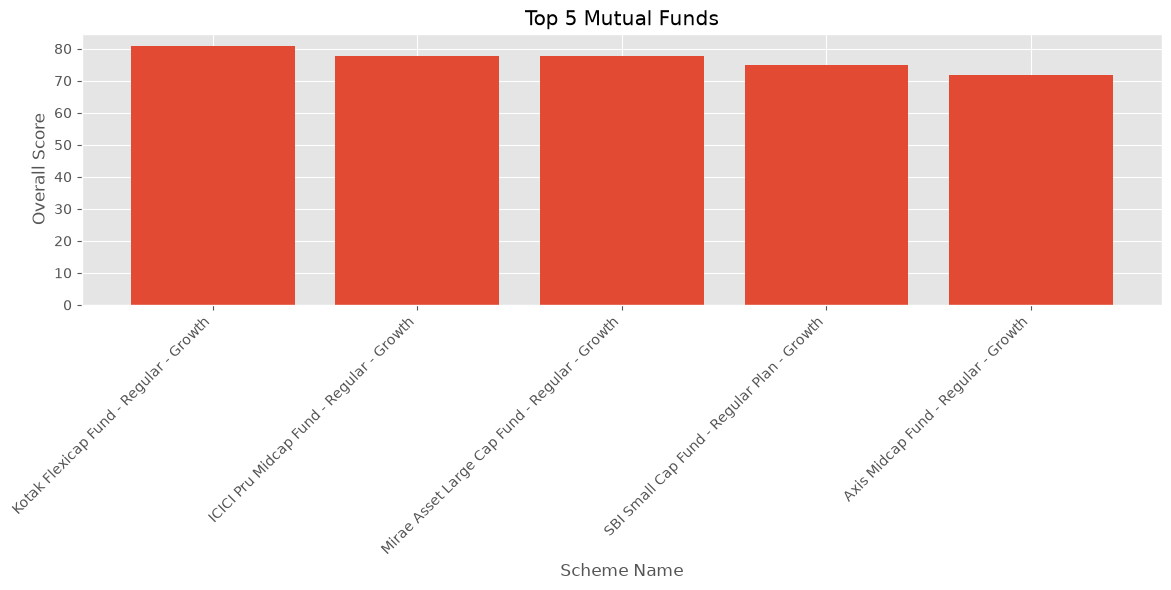

In [37]:
top5 = scorecard.head(5)

plt.figure(figsize=(12,6))

plt.bar(
    top5["scheme_name"],
    top5["Score"]
)

plt.xticks(rotation=45, ha="right")

plt.title("Top 5 Mutual Funds")

plt.xlabel("Scheme Name")
plt.ylabel("Overall Score")

plt.tight_layout()

plt.savefig("../reports/top5_funds.png")

plt.show()

In [38]:
print("=" * 60)
print("PERFORMANCE ANALYTICS SUMMARY")
print("=" * 60)

print(f"Total Funds Analysed : {len(scorecard)}")
print(f"Average CAGR         : {scorecard['CAGR (%)'].mean():.2f}%")
print(f"Average Sharpe Ratio : {scorecard['Sharpe'].mean():.2f}")

print("\nTop Performing Fund")
print("-------------------")

print(scorecard.iloc[0][
    [
        "scheme_name",
        "fund_house",
        "CAGR (%)",
        "Sharpe",
        "Score"
    ]
])

PERFORMANCE ANALYTICS SUMMARY
Total Funds Analysed : 40
Average CAGR         : 16.74%
Average Sharpe Ratio : 0.65

Top Performing Fund
-------------------
scheme_name    Kotak Flexicap Fund - Regular - Growth
fund_house                          Kotak Mahindra MF
CAGR (%)                                        30.91
Sharpe                                         1.3382
Score                                         80.6875
Name: 22, dtype: object


# Performance Analytics Summary

## Key Achievements

- Loaded historical NAV and performance data from SQLite.
- Calculated daily returns for all mutual funds.
- Computed CAGR for every scheme.
- Calculated annualized Sharpe Ratio.
- Used Alpha and Beta values from the performance dataset.
- Computed Maximum Drawdown for each fund.
- Built a composite fund score using CAGR, Sharpe Ratio, Alpha, expense ratio, and drawdown.
- Exported analytical reports as CSV files.
- Visualized the Top 5 mutual funds using a bar chart.